# 🎵 Uçtan Uca (End-to-End) Spotify Hit Tahmini Pipeline
Bu notebook, takımdaki Agent'ların parça parça yaptığı işlemlerin (Veri Yükleme, EDA, Veri Temizleme (DataPrep), Feature Engineering ve Model Training kısımlarının) **hepsini tek bir akışta** toplar.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Veri Yükleme ve Hızlı İnceleme

In [2]:
df = pd.read_csv('../data/raw/dataset.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Veri Temizleme ve Özellik Mühendisliği (Data Preparation)

In [3]:
# 1. Kategorik Eksikleri Doldurma
df['artists'] = df['artists'].fillna('Unknown')
df['album_name'] = df['album_name'].fillna('Unknown')
df['track_name'] = df['track_name'].fillna('Unknown')

# 2. Aykırı Değer Baskılama (Capping - IQR Metodu)
for col in ['duration_ms', 'loudness', 'tempo']:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# 3. Yeni Özellik Çıkarımı (Feature Engineering)
# Müzik süresini (milisaniye/saniye) dakikaya çevirip orijinal sütunu kaldırıyoruz (redundancy engellemek için)
if 'duration_ms' in df.columns:
    df['duration_min'] = df['duration_ms'] / 60000.0

df['energy_loudness_ratio'] = df['energy'] / (df['loudness'] + 60 + 1e-5)
df['danceability_squared'] = df['danceability'] ** 2

bins = [-np.inf, 90, 130, np.inf]
labels = [0, 1, 2] # 0: Yavaş, 1: Orta, 2: Hızlı
df['tempo_encoded'] = pd.cut(df['tempo'], bins=bins, labels=labels).astype(int)

if 'explicit' in df.columns:
    df['is_explicit'] = df['explicit'].astype(int)
    df.drop(columns=['explicit'], inplace=True)

# 4. Gereksiz Verileri Çıkarma (Metinler ve Eski Süre Sütunu)
drop_cols = ['track_id', 'artists', 'album_name', 'track_name', 'track_genre', 'duration_ms']
df_cleaned = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
print("Veri Temizleme Tamamlandı! Yeni Boyut:", df_cleaned.shape)

Veri Temizleme Tamamlandı! Yeni Boyut: (114000, 19)


## 3. Makine Öğrenmesi (Model Training)

In [4]:
# Performans için %20 Sampling yapıyoruz
df_sample = df_cleaned.sample(frac=0.2, random_state=42)

X = df_sample.drop(columns=['popularity'])
y = df_sample['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Eğitim Seti Boyutu:", X_train_scaled.shape)

Eğitim Seti Boyutu: (18240, 18)


In [5]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1)
}

results = []
print("Bütün Modeller Eğitiliyor ve Değerlendiriliyor...\n")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    
    results.append({'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})

res_df = pd.DataFrame(results).sort_values(by='R2', ascending=False).reset_index(drop=True)

# Renklendirilmiş şık sonuç tablosu (DataFrame Style)
res_df.style.background_gradient(cmap='viridis', subset=['R2']).background_gradient(cmap='Reds', subset=['RMSE', 'MAE'])

Bütün Modeller Eğitiliyor ve Değerlendiriliyor...



,Model,R2,RMSE,MAE
0,XGBoost,0.160496,20.393554,16.182735
1,LightGBM,0.146894,20.558107,16.779827
2,Random Forest,0.130636,20.753071,16.980488
3,Gradient Boosting,0.078828,21.362493,17.636668
4,Ridge Regression,0.024924,21.978631,18.346631
5,Lasso Regression,0.021679,22.015172,18.422953
6,ElasticNet,0.020587,22.027463,18.438157
7,Decision Tree,-0.003642,22.298253,17.867976


## 4. Sonuçların Görselleştirilmesi

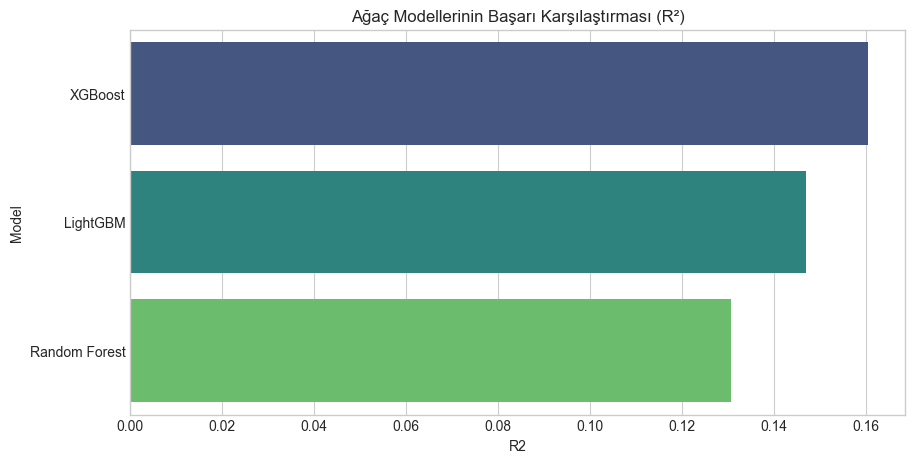

In [ ]:
# Yan yana iki grafik: R2 Skorları ve Hata (RMSE)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R2 Grafiği
sns.barplot(data=res_df, x='R2', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('Modellerin Modellerin R² (Açıklanabilirlik) Karşılaştırması')
axes[0].set_xlabel('R² Skoru (Yüksek daha iyi)')
axes[0].set_ylabel('')

# RMSE Grafiği
sns.barplot(data=res_df.sort_values(by='RMSE', ascending=True), x='RMSE', y='Model', palette='magma', ax=axes[1])
axes[1].set_title('Modellerin RMSE (Hata) Karşılaştırması')
axes[1].set_xlabel('RMSE Skoru (Düşük daha iyi)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. En İyi Model ile Özellik Önemleri (Feature Importances)
Yukarıdaki tablodan çıkan en yüksek $R^2$ performansına sahip modeli alıp, modelin en çok etkilendiği veri sütunlarını (Feature Importance) inceliyoruz. Aynı zamanda modelin Gerçek ve Tahmin arasındaki dağılımını grafiğe döküyoruz.

En İyi Model Seçildi: XGBoost


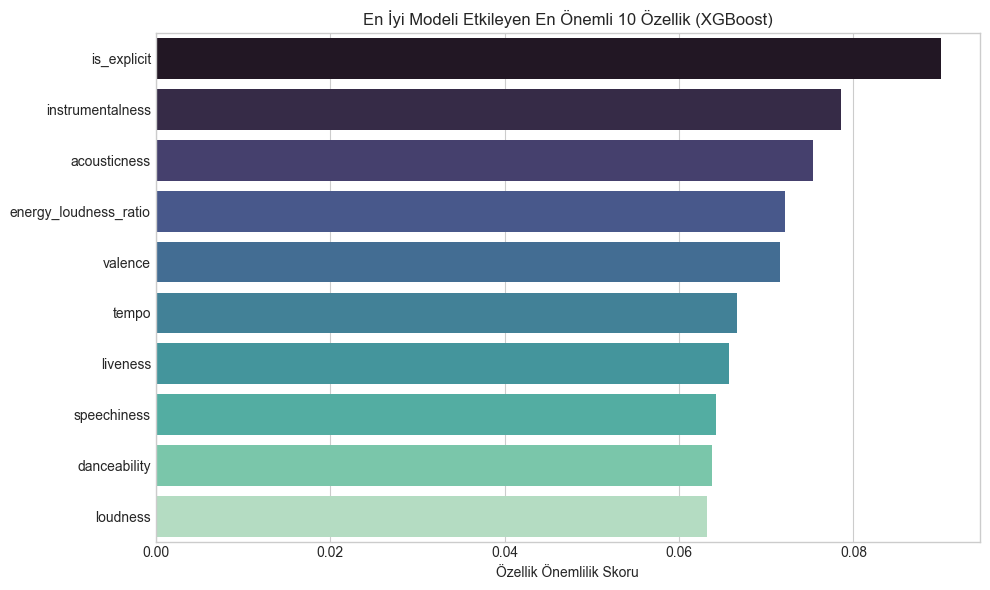

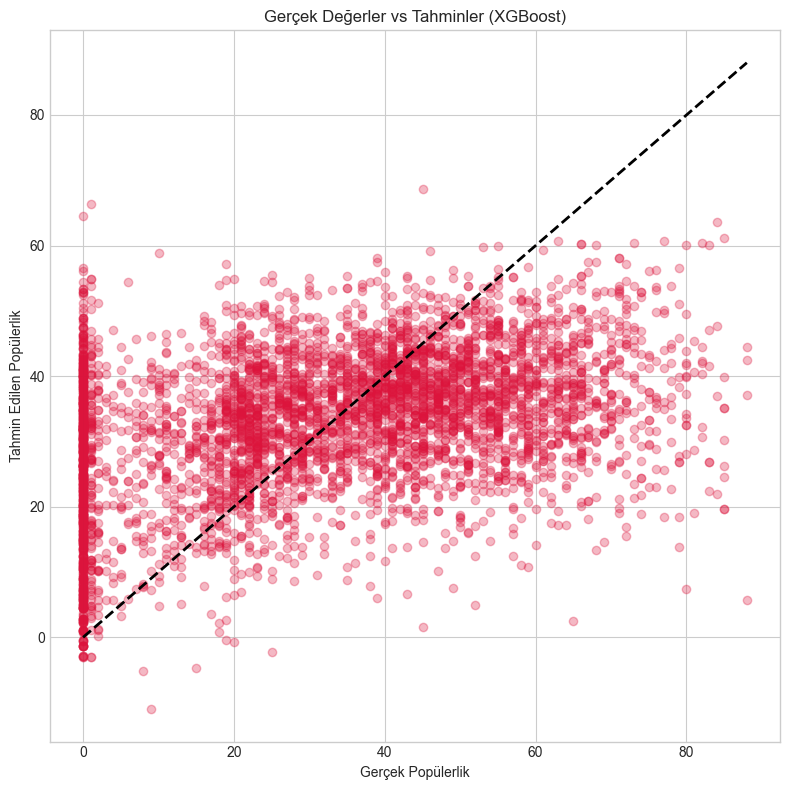

In [6]:
best_model_name = res_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"En İyi Model Seçildi: {best_model_name}")

# Eğer en iyi model tree tabanlıysa Özellik Önemliliğini çizebiliriz
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_imp.head(10).values, y=feat_imp.head(10).index, palette='mako')
    plt.title(f'En İyi Modeli Etkileyen En Önemli 10 Özellik ({best_model_name})')
    plt.xlabel('Özellik Önemlilik Skoru')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} algoritması doğrudan özelliği önem derecelendirmesi (feature_importances_) desteklemiyor.")

# --- Gerçek ve Tahmin Saçılım (Scatter) Grafiği ---
best_preds = best_model.predict(X_test_scaled)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_preds, alpha=0.3, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Gerçek Popülerlik')
plt.ylabel('Tahmin Edilen Popülerlik')
plt.title(f'Gerçek Değerler vs Tahminler ({best_model_name})')
plt.tight_layout()
plt.show()